# Demand Forecasting

## Data and Libraries Import

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import os
from pathlib import Path
from dotenv import load_dotenv,find_dotenv

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

from statsforecast import StatsForecast
from statsforecast.models import Naive, AutoARIMA, WindowAverage, SeasonalNaive, HistoricAverage

from sqlalchemy import create_engine, text


import warnings
warnings.filterwarnings('ignore')

In [2]:
env_path =Path.cwd()/"github_repo_cloned"/"india-logistics-hub-optimizer"/".env"
load_dotenv(env_path) 

HOST = os.getenv("DB_HOST")
USER = os.getenv("DB_USER")
PASSWORD = os.getenv("DB_PASSWORD")
PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
OUTPUT_DIR = os.getenv("OUTPUT_DIR")

In [3]:
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}")


def sql(query, engine = engine):
    with engine.connect() as conn:
        df = pd.read_sql(text(query),conn)
    return df

In [4]:
query = "select * from forecasting_data"

data = sql(query=query,engine=engine)

In [5]:
data.head()

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
0,andaman and nicobar,2018-07,7499.0,194.66,7499.0,194.66
1,andhra pradesh,2018-07,1931596.0,66363.08,1931596.0,66363.08
2,arunachal pradesh,2018-07,19147.0,394.15,19147.0,394.15
3,assam,2018-07,601740.0,17874.21,601740.0,17874.21
4,bihar,2018-07,616137.0,18787.14,616137.0,18787.14


## Initial Data Check

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state          3650 non-null   object 
 1   date           3650 non-null   object 
 2   bill_volume    3650 non-null   float64
 3   bill_amount    3650 non-null   float64
 4   avg_bill_3m    3650 non-null   float64
 5   avg_amount_3m  3650 non-null   float64
dtypes: float64(4), object(2)
memory usage: 171.2+ KB


In [7]:
data['state'].nunique()

38

In [8]:
data['date']

0       2018-07
1       2018-07
2       2018-07
3       2018-07
4       2018-07
         ...   
3645    2026-07
3646    2026-07
3647    2026-07
3648    2026-07
3649    2026-07
Name: date, Length: 3650, dtype: object

In [9]:
data['date']=pd.to_datetime(data['date'],format="%Y-%m").dt.to_period("M")

In [10]:
data.sample(5)

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
3276,chhattisgarh,2025-10,1813320.0,67196.65,1882526.33,70094.86
31,telangana,2018-07,1957402.0,65408.49,1957402.00,65408.49
1801,west bengal,2022-06,3965978.0,141209.19,4058766.00,145274.71
3384,andaman and nicobar,2026-01,19248.0,633.63,19212.00,636.93
2881,jharkhand,2024-11,1458575.0,53581.20,1527304.00,54705.60


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   state          3650 non-null   object   
 1   date           3650 non-null   period[M]
 2   bill_volume    3650 non-null   float64  
 3   bill_amount    3650 non-null   float64  
 4   avg_bill_3m    3650 non-null   float64  
 5   avg_amount_3m  3650 non-null   float64  
dtypes: float64(4), object(1), period[M](1)
memory usage: 171.2+ KB


In [12]:
data.isnull().sum()

state            0
date             0
bill_volume      0
bill_amount      0
avg_bill_3m      0
avg_amount_3m    0
dtype: int64

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_volume,3650.0,2.885065e+06,4.335539e+06,20.00,63548.5000,952044.000,3.877952e+06,27217002.00
bill_amount,3650.0,8.255815e+04,1.216688e+05,0.38,2669.0000,33347.620,1.171698e+05,851046.04
avg_bill_3m,3650.0,2.851899e+06,4.266516e+06,24.00,64748.6675,971766.665,3.814462e+06,26612414.67
avg_amount_3m,3650.0,8.159119e+04,1.194640e+05,0.98,2681.3400,33650.645,1.173938e+05,817054.51


In [14]:
data= data.sort_values('date')

In [15]:
data['date']=data['date'].dt.to_timestamp()

## Visualization

In [78]:
def plot_bill_trend(column, title="", filename=None):
    plt.figure(figsize=(25,8))
    ax = sns.lineplot(x='date', y=column, data=data, color='#1B7A72')
    ax.set_title(title, weight='bold', fontsize=20)
    plt.xlabel("Date", fontsize=10, weight='bold')
    plt.ylabel("Bill Volume", fontsize=15, weight='bold')

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', which='major', labelsize=11, pad=20)
    ax.tick_params(axis='x', which='minor', labelsize=8, colors='black')

    lockdown_start = pd.Timestamp('2020-03-01')
    lockdown_end = pd.Timestamp('2020-06-30')
    ax.axvspan(lockdown_start, lockdown_end, color='red', alpha=0.12, zorder=0)
    ax.text(lockdown_start + (lockdown_end - lockdown_start)/2, ax.get_ylim()[1]*0.95,
            'COVID-19\nLockdown', ha='center', va='top', fontsize=9, color='darkred', weight='bold')

    sns.despine(left=True, bottom=True)
    ax.grid(axis='y', alpha=0.3)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()

    filename = filename or f"{column}_trend.png"
    plt.savefig(f"{OUTPUT_DIR}/{filename}", dpi=150, bbox_inches='tight')
    plt.show()

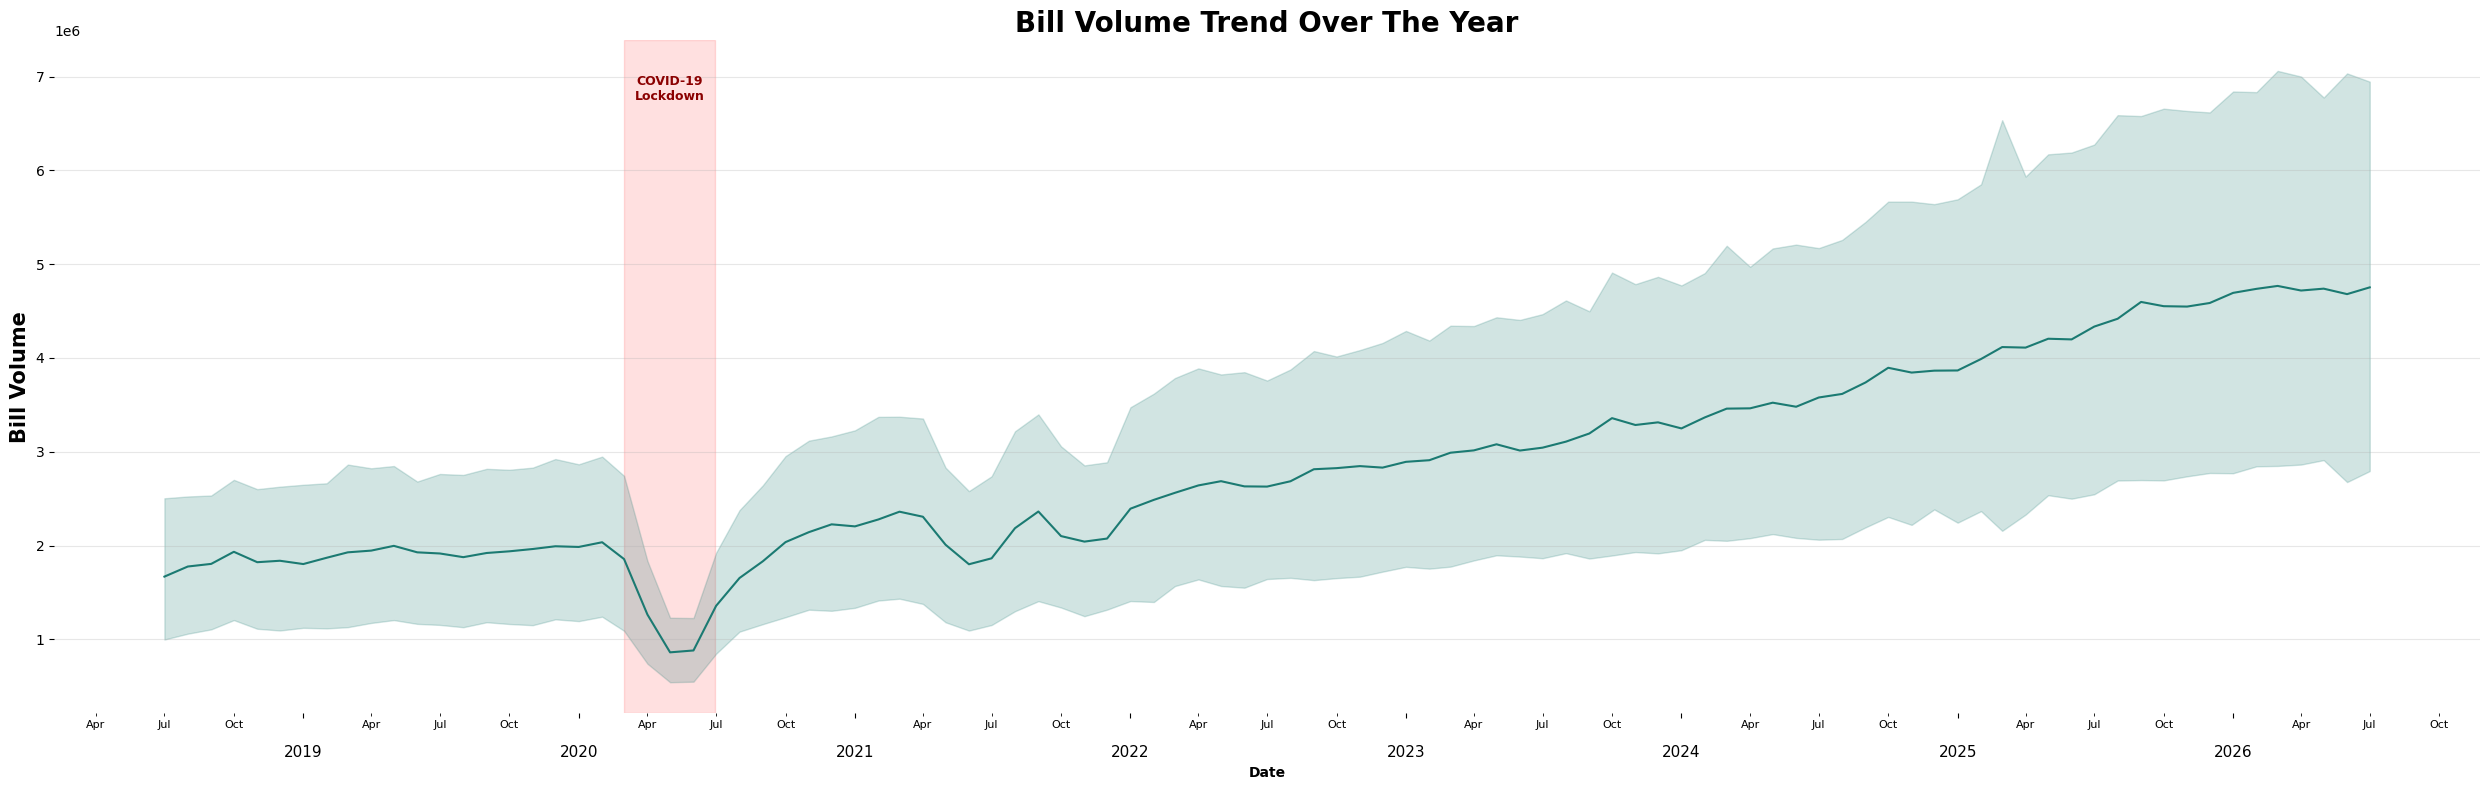

In [17]:
plot_bill_trend('avg_bill_3m',title="Bill Volume Trend Over The Year",filename="bill_volume_trend.png")

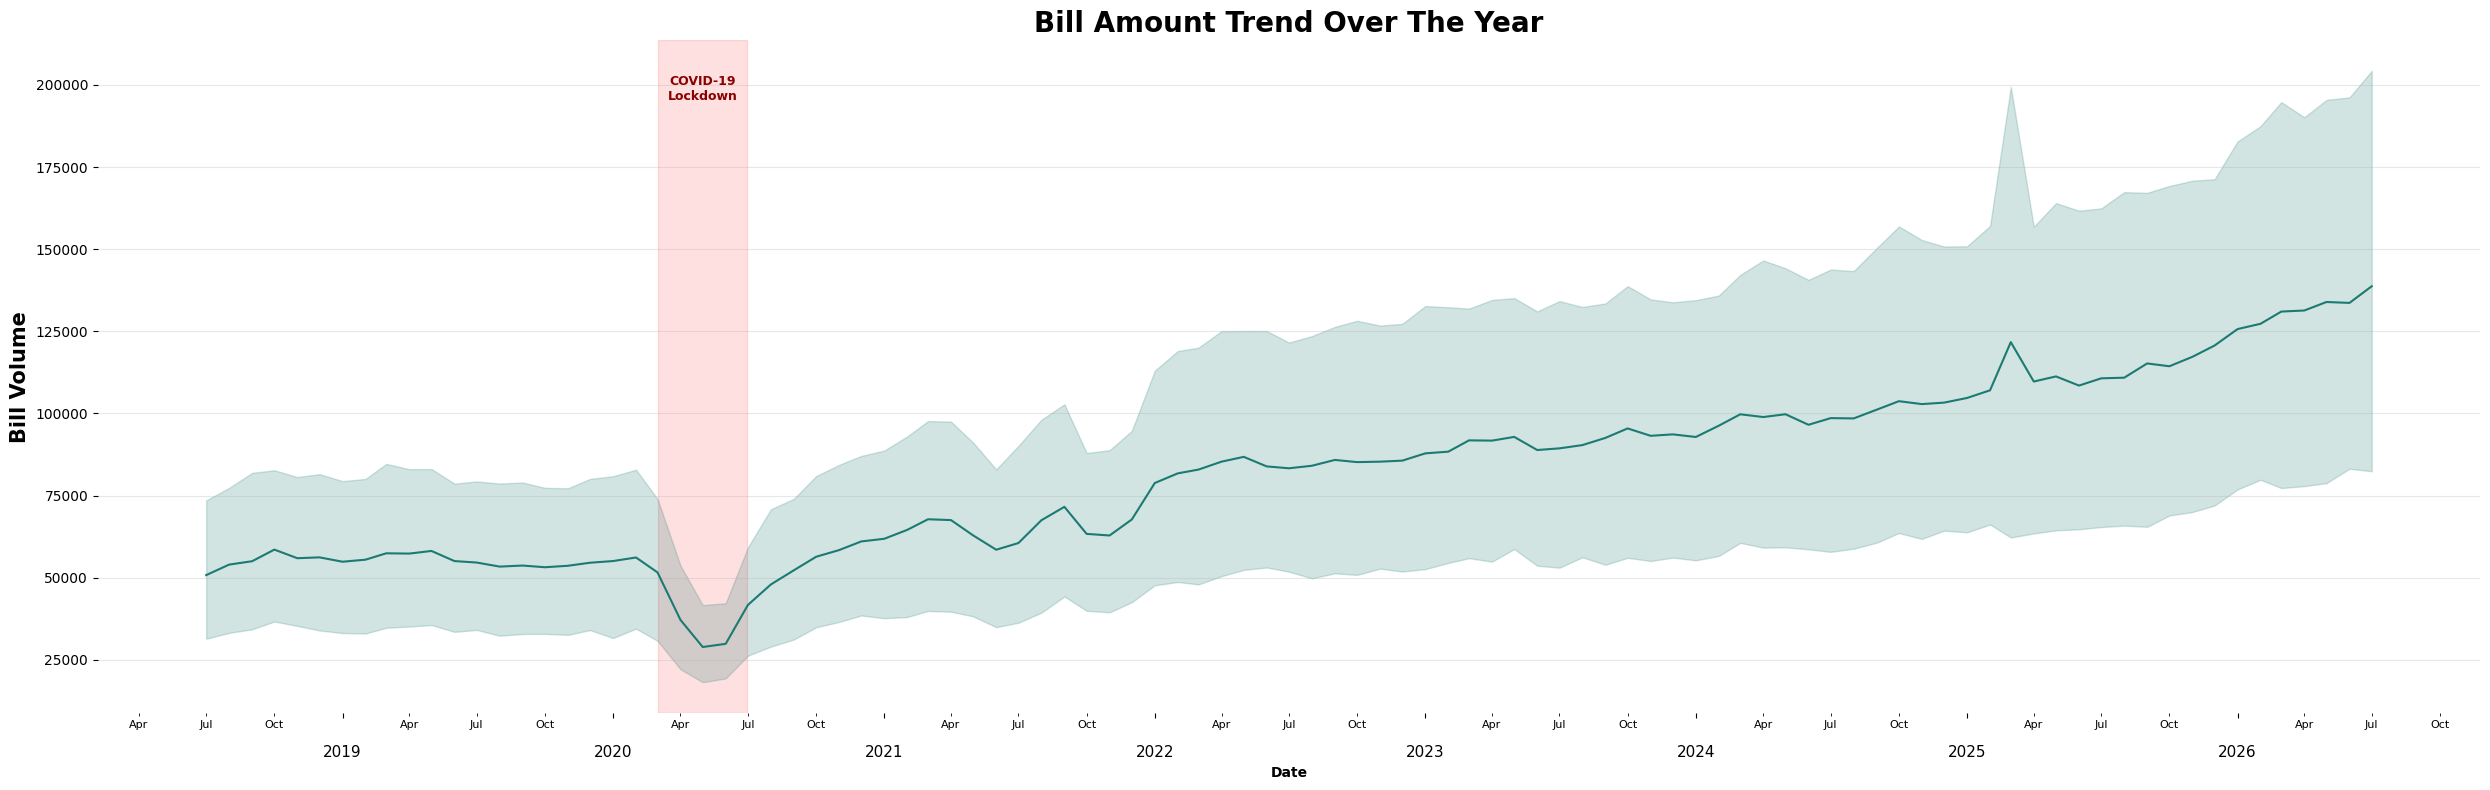

In [18]:
plot_bill_trend('avg_amount_3m',title="Bill Amount Trend Over The Year",filename="bill_amount_trend.png")

## Forecasting

In [19]:
data.head()

,state,date,bill_volume,bill_amount,avg_bill_3m,avg_amount_3m
0,andaman and nicobar,2018-07-01,7499.0,194.66,7499.0,194.66
1,andhra pradesh,2018-07-01,1931596.0,66363.08,1931596.0,66363.08
7,dadra and nagar haveli,2018-07-01,362641.0,16424.18,362641.0,16424.18
6,chhattisgarh,2018-07-01,610475.0,25003.50,610475.0,25003.50
2,arunachal pradesh,2018-07-01,19147.0,394.15,19147.0,394.15


In [20]:
volume_data = data[['state','date','bill_volume']].rename(columns={'state':'unique_id','date':'ds','bill_volume':'y'})
amount_data = data[['state','date','bill_amount']].rename(columns={'state':'unique_id','date':'ds','bill_amount':'y'})

In [21]:
volume_data_sorted = volume_data.sort_values(by =['unique_id','ds'])
amount_data_sorted = amount_data.sort_values(by=['unique_id','ds'])

In [22]:
volume_train = volume_data_sorted\
    .groupby('unique_id')\
        .apply(lambda x: x.iloc[:-12])\
            .reset_index(drop=True)



volume_test = volume_data_sorted\
    .groupby('unique_id')\
        .apply(lambda x: x.iloc[-12:])\
            .reset_index(drop=True)

amount_train = amount_data\
    .groupby('unique_id')\
        .apply(lambda x: x.iloc[:-12])\
            .reset_index(drop=True)



amount_test = amount_data\
    .groupby('unique_id')\
        .apply(lambda x: x.iloc[-12:])\
            .reset_index(drop=True)

In [23]:
models = [
    Naive(),
    WindowAverage(window_size=3),
    HistoricAverage(),
    SeasonalNaive(season_length=12),
    AutoARIMA(seasonal=False,alias='ARIMA'),
    AutoARIMA(season_length=12, alias="SARIMA")
]

In [24]:
volume_forecast_model = StatsForecast(models=models, freq='MS')
amount_forecast_model = StatsForecast(models=models, freq='MS')

volume_forecast_model.fit(volume_train)
amount_forecast_model.fit(amount_train)


StatsForecast(models=[Naive,WindowAverage,HistoricAverage,SeasonalNaive,ARIMA,SARIMA])

In [25]:
volume_cv_results = volume_forecast_model.cross_validation(
    df = volume_train,
    n_windows=5,
    h=12,
    step_size = 6
)

amount_cv_results = amount_forecast_model.cross_validation(
    df = amount_train,
    n_windows=5,
    h=12,
    step_size = 6
)

In [26]:
volume_evaluation = evaluate(
    volume_cv_results,
    metrics=[mae,rmse,mape],
    models=['Naive', 'WindowAverage', 'HistoricAverage', 'SeasonalNaive', 'ARIMA', 'SARIMA']
)

amount_evaluation = evaluate(
    amount_cv_results,
    metrics=[mae,rmse,mape],
    models=['Naive', 'WindowAverage', 'HistoricAverage', 'SeasonalNaive', 'ARIMA', 'SARIMA']
)

In [27]:
volume_eval_summary = volume_evaluation.groupby('metric')\
    [['Naive', 'WindowAverage', 'HistoricAverage', 'SeasonalNaive', 'ARIMA', 'SARIMA']].mean().round(2)


amount_eval_summary = amount_evaluation.groupby('metric')\
    [['Naive', 'WindowAverage', 'HistoricAverage', 'SeasonalNaive', 'ARIMA', 'SARIMA']].mean().round(2)

In [28]:
def plot_eval_summary(eval_summary, figsize=(18,4)):
    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    for ax, metric in zip(axes, eval_summary.index):
        values = eval_summary.loc[metric]
        ax.barh(eval_summary.columns, values, color=colors)
        ax.axvline(values.min(), color='red', linestyle='--', linewidth=1)
        ax.set_title(metric.upper())
        ax.set_xlabel(metric)

    plt.tight_layout()
    plt.show()

In [29]:
def plot_forecast(state=None, actual=None, forecast=None, figsize=(24,5)):
    if state:
        actual_data = actual[actual['unique_id'] == state]
        forecast_data = forecast[forecast['unique_id'] == state].rename(columns={'SARIMA': 'SARIMA'})
        title = f'Bill Volume: Actual vs Forecast — {state}'
    else:
        actual_data = actual.groupby('ds')['y'].sum().reset_index()
        forecast_data = forecast.groupby('ds')['SARIMA'].sum().reset_index()
        title = 'Total Bill Volume: Actual vs Forecast'

    # stitch actual and forecast so the lines connect (applies to both cases now)
    last_actual = actual_data.iloc[[-1]].rename(columns={'y': 'SARIMA'})
    forecast_data = pd.concat([last_actual[['ds', 'SARIMA']], forecast_data])

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(actual_data['ds'], actual_data['y'], label='Actual', color='#4C72B0', linewidth=2.5)
    ax.plot(forecast_data['ds'], forecast_data['SARIMA'], label='Forecast', linestyle='--', color='#C44E52', linewidth=2.5)

    ax.fill_between(forecast_data['ds'], forecast_data['SARIMA'], color='#C44E52', alpha=0.15)

    ax.axvline(actual_data['ds'].max(), color='gray', linestyle=':', linewidth=1)
    ax.text(actual_data['ds'].max(), ax.get_ylim()[1]*0.95, ' forecast starts', fontsize=9, color='gray')

    ax.legend()
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Bill Volume')

    sns.despine(ax=ax)
    plt.show()

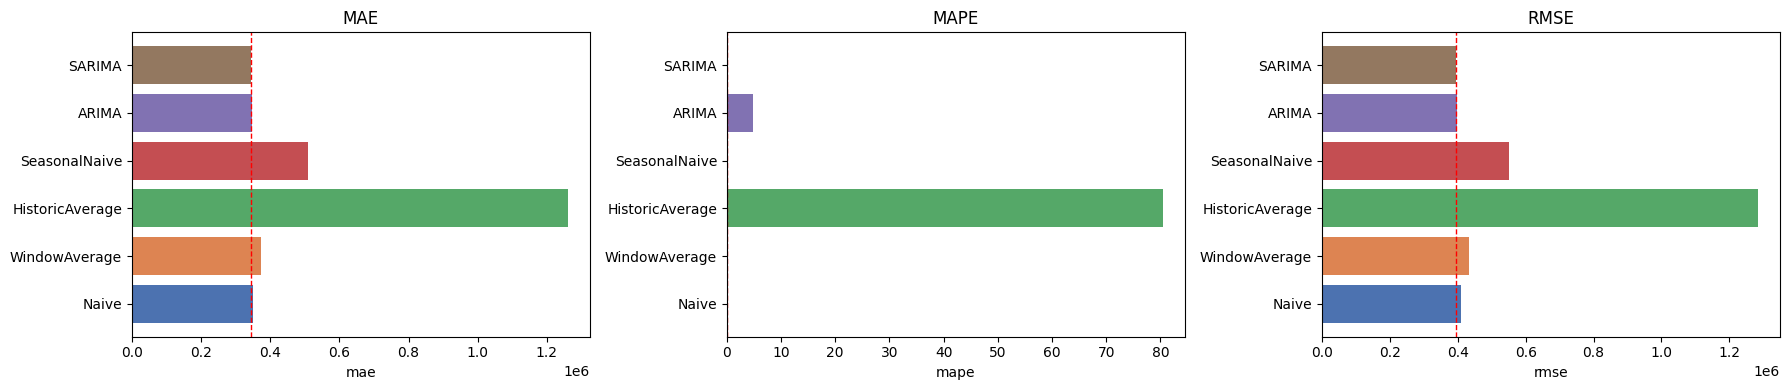

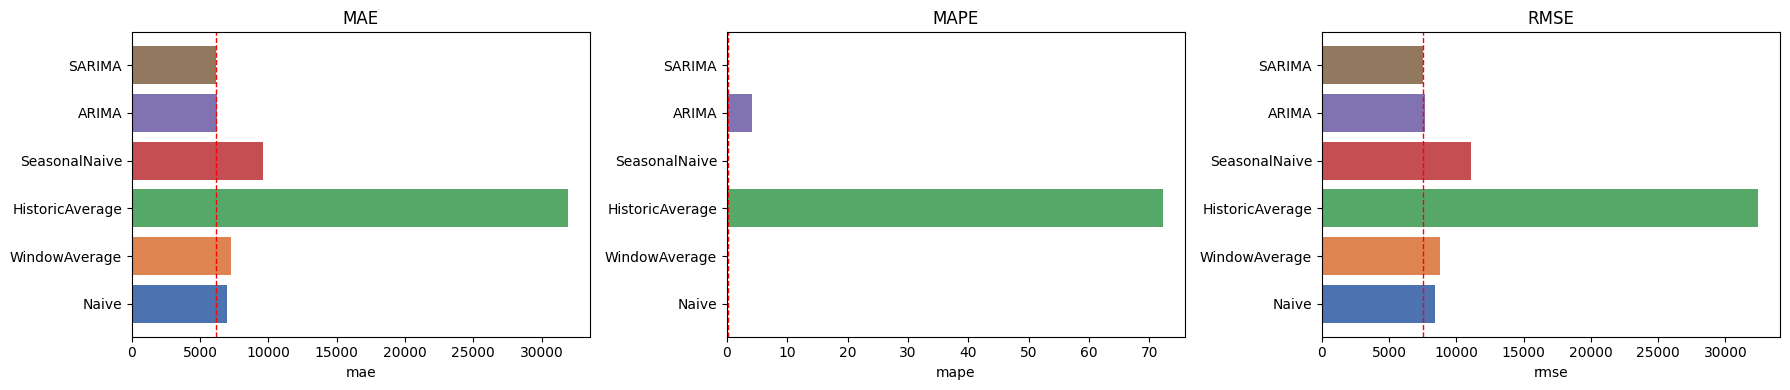

In [30]:
plot_eval_summary(volume_eval_summary)
plot_eval_summary(amount_eval_summary)

In [31]:
final_volume_forecast = StatsForecast(models=[AutoARIMA(season_length=12,alias = "SARIMA")],freq="MS")
final_volume_forecast.fit(volume_data_sorted)
future_volume_forecast = final_volume_forecast.predict(h=12)


final_amount_forecast = StatsForecast(models=[AutoARIMA(season_length=12,alias = "SARIMA")],freq="MS")
final_amount_forecast.fit(amount_data_sorted)
future_amount_forecast = final_amount_forecast.predict(h=12)

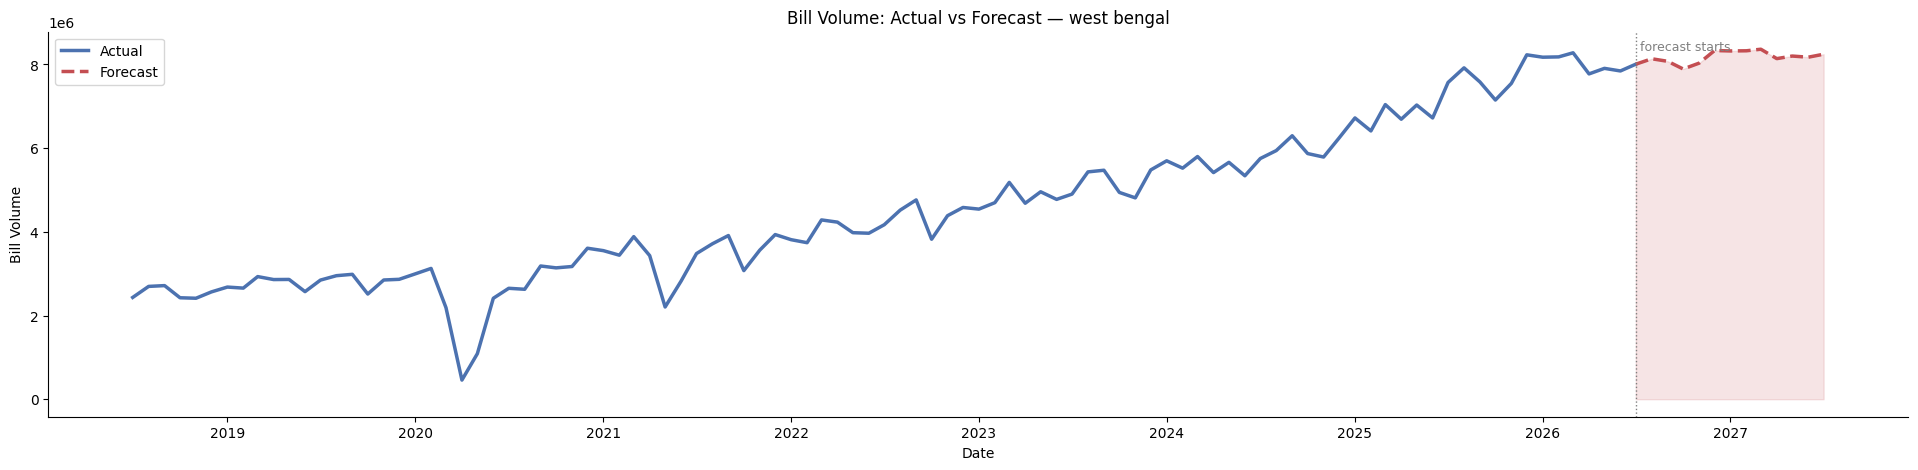

In [36]:
plot_forecast(state='west bengal',actual=volume_data_sorted,forecast=future_volume_forecast)

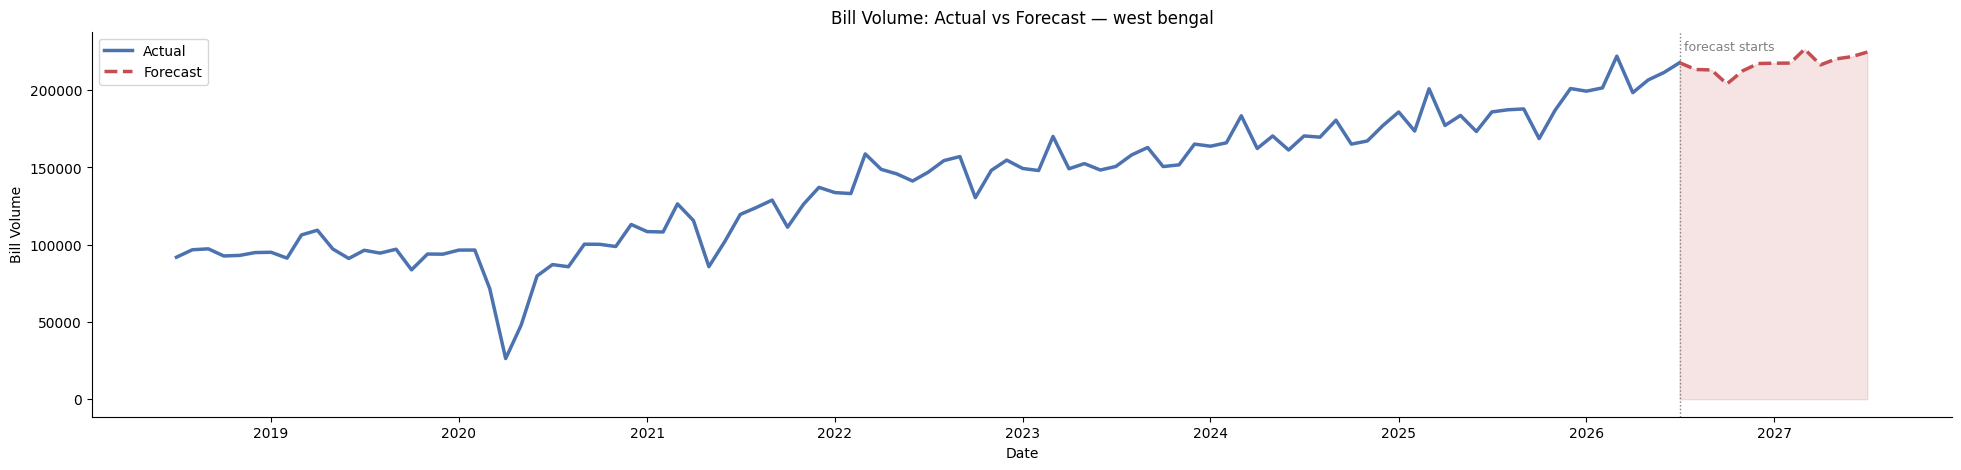

In [37]:
plot_forecast(state='west bengal',actual=amount_data_sorted,forecast=future_amount_forecast)

In [ ]:
import pickle

models_dir = Path.cwd()/"github_repo_cloned"/"india-logistics-hub-optimizer"/"models"

with open(models_dir / "volume_sarima.pkl", "wb") as f:
    pickle.dump(final_volume_forecast, f)

with open(models_dir / "amount_sarima.pkl", "wb") as f:
    pickle.dump(final_amount_forecast, f)

In [48]:
models_dir = Path.cwd()/"github_repo_cloned"/"india-logistics-hub-optimizer"/"models"

volume_data_sorted.to_csv(models_dir/"volume_data_sorted.csv", index=False)
amount_data_sorted.to_csv(models_dir/"amount_data_sorted.csv", index=False)

In [74]:
amount_temp = future_amount_forecast.groupby('unique_id')['SARIMA'].sum().reset_index().sort_values(by='SARIMA',ascending=False).head(10)
amount_temp['unique_id'] = amount_temp['unique_id'].apply(lambda x: x.title())

volume_temp = future_volume_forecast.groupby('unique_id')['SARIMA'].sum().reset_index().sort_values(by='SARIMA',ascending=False).head(10)
volume_temp['unique_id'] = volume_temp['unique_id'].apply(lambda x: x.title())


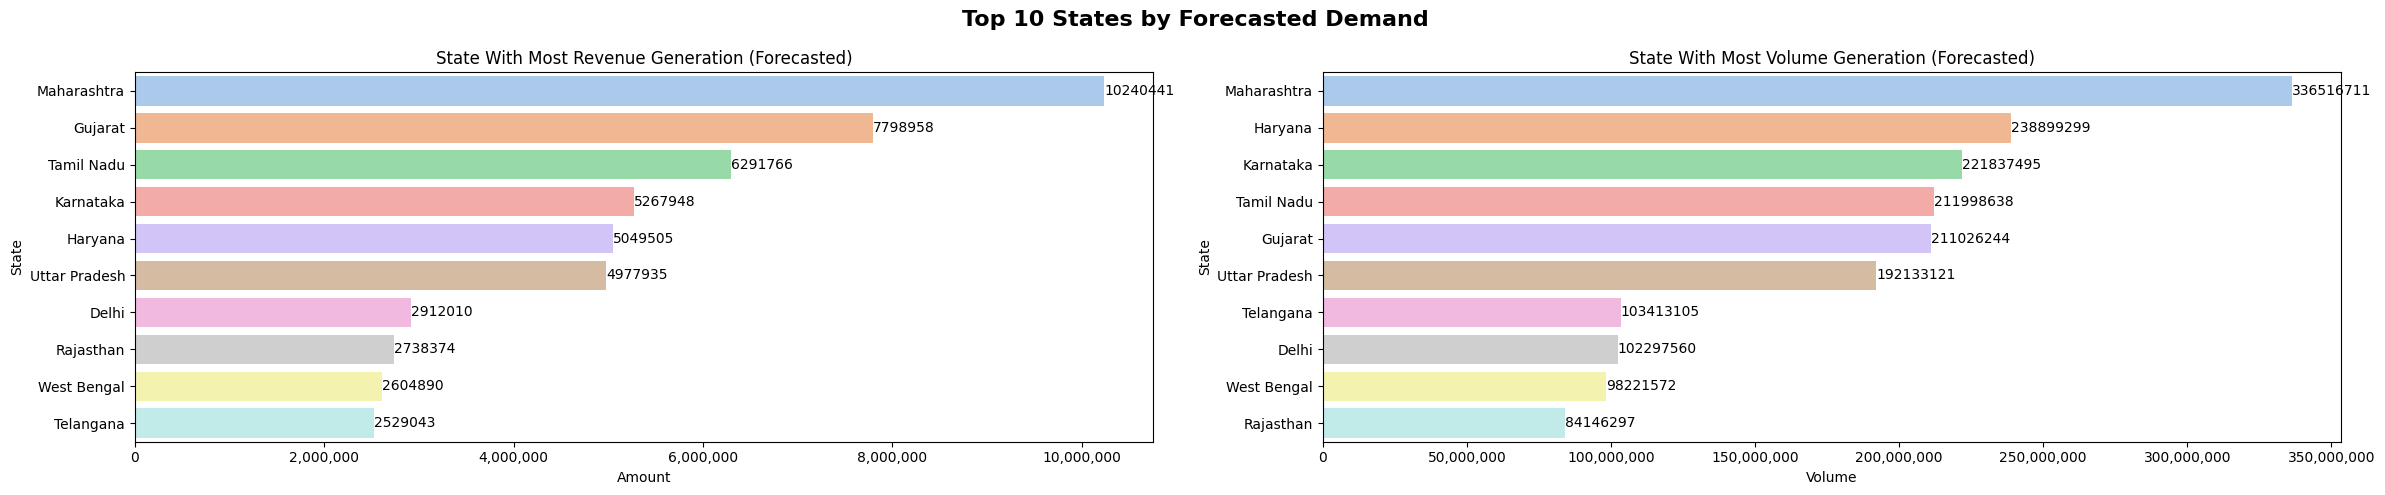

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(24,5))

sns.barplot(x='SARIMA', y='unique_id', data=amount_temp, palette='pastel', ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container=container, fmt='%.0f')
axes[0].set_title('State With Most Revenue Generation (Forecasted)')
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("State")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

sns.barplot(x='SARIMA', y='unique_id', data=volume_temp, palette='pastel', ax=axes[1])
for container in axes[1].containers:
    axes[1].bar_label(container=container, fmt='%.0f')
axes[1].set_title('State With Most Volume Generation (Forecasted)')
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("State")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Top 10 States by Forecasted Demand', fontsize=16, weight='bold')
plt.tight_layout()

filename = "top10_states_forecast.png"
plt.savefig(f"{OUTPUT_DIR}/{filename}", dpi=150, bbox_inches='tight')
plt.show()